# CREDIT LOAN RISK DATA ANALYSIS

Credits to Lao Tse for the dataset.
You can access the dataset [here](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

### Data Analysis and Exploration

In this part of the notebook, the cleaned data are examined and analyzed for to answer the questions stated on the previous notebook. The hypothesis of the questions are formed based on the exploration of data conducted in this notebook. With hypothesis, the following questions are:

* What is the overall default rate in our dataset?
  * *Ho*: The default rate is less than 20%.
* How does the DTI (Debt to Income) ratio correlate with the likelihood of defaulted loans? 
  * *Ho*: The higher the DTI, the more loans are defaulted. 
* Which combination of age, income, loan intent, loan amount, loan grade, and home ownership has the highest chance of defaulting?
  *  *Ho*: The younger, less income, debt consolidation, higher amount, lower grade and renting borrowers are mosty likely to default.
* What is the average loan amount requested per age group?
  *  *Ho*: 18 - 35 average around $30,000, 36-50 average around $50,0000, while 51 to 65 are around $100,000
* Do borrower with longer credit history borrow more money?
  *  *Ho*: Yes, the longer the credit history, the more money is borrowed

##### Age

Examining the age of the borrowers can help in analyzing the credit risk of borrowers and how it affects the loan and its attributes. The analyst used the following code to proceed:

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [225]:
person_ages = pd.read_csv('cleaned_data/cleaned_person_ages.csv')
person_ages.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Clean_person_age  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


In [226]:
person_ages.describe()

,Clean_person_age
count,32581.000000
mean,27.719254
std,6.206590
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,94.000000


The code shows the statistical summary of the cleaned data. Grouping the ages into subsets can provide more insights such as how much of the age groups occupy most of the data. This can be done using the following:

In [227]:
age_young_group = person_ages[(person_ages >= 18) & (person_ages <= 25)] # Get all ages between 18 and 25
age_middle_group = person_ages[(person_ages >= 26) & (person_ages <= 40)] # Get all ages between 26 and 40
age_old_group = person_ages[(person_ages >= 41) & (person_ages <= 55)] # Get all ages between 41 and 55
age_pre_retire_group = person_ages[(person_ages >= 56) & (person_ages <= 65)] # Get all ages between 56 and 65
age_retire_group = person_ages[person_ages >= 66] # Get all ages 66 and above

# Store the count of each subgroup into a dataframe
age_groups = pd.DataFrame([
  age_young_group.count(), 
  age_middle_group.count(),
  age_old_group.count(),
  age_pre_retire_group.count(),
  age_retire_group.count()
  ], index=['18-25','26-40','41-55','56-65','66+']
)
age_groups = age_groups.rename(columns={'Clean_person_age':'Count'}) # Change column name
age_groups


,Count
18-25,15354
26-40,15735
41-55,1358
56-65,104
66+,30


Text(0.5, 1.0, 'Age Groups and Number of borrowers.')

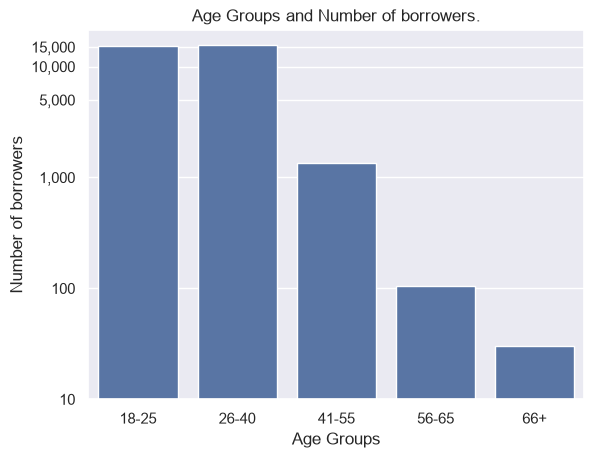

In [228]:
sb.set_theme() # Set color theme
chart = sb.barplot(data=age_groups, x=age_groups.index, y='Count') # Plot the data with x as the age groups and y as the count
chart.set_yscale('log', base=10) # Scale the y-axis as log base of 10
chart.set_yticks([10, 100, 1000, 5000, 10000,15000])  # Display these specific ticks
chart.set_yticklabels(['10', '100', '1,000', '5,000', '10,000','15,000']) # Set the labels
chart.yaxis.set_minor_formatter(plt.NullFormatter()) # Show only the needed tick labels

chart.set_xlabel('Age Groups') # x label
chart.set_ylabel('Number of borrowers') # y label
chart.set_title('Age Groups and Number of borrowers.') # title

The results show the number of borrowers divided into separate subgroups. The group of `26-40` ranks the most with the highest number of borrowers followed by `18-25`, then `41-55`, then `56-65` then finally, `66+`. Compared to `18-25` and `26-40`, the gap between them ranges immensely, from `15,354` to `1,358`, `1034`, and `38`. This shows that majority of the borrowers have the ages `18-40`. Basically diving the ages into two groups. To demonstrate the differences, the following pie chart will show the difference:

Text(0.5, 1.0, 'Two Groups of Borrowers By Ages')

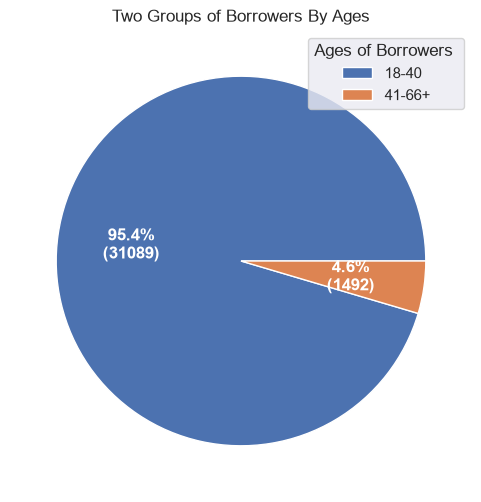

In [229]:
first_group = age_young_group.count() + age_middle_group.count() # Get first group
second_group = age_old_group.count() + age_pre_retire_group.count() + age_retire_group.count() # Get second group
groups = pd.DataFrame([first_group, second_group]) # store as dataframe

fig, ax = plt.subplots(figsize=(6,6)) # Create one subplot
pie = ax.pie(groups['Clean_person_age']) # Make piechart of the column

# Set pie chart labels
ax.pie_label(pie, '{frac:.1%}\n({absval:d})', 
              textprops=dict(color='w', size=12, weight='bold')
              )

# Set pie chart legends
ax.legend(pie.wedges,['18-40','41-66+'],
            title='Ages of Borrowers '
           )

# Set pie chart title
ax.set_title('Two Groups of Borrowers By Ages')

##### Income

Income is very important as it is the main way a loan can be paid. For loaners, this is the basis on how long a loan will last and the basis for the DTI. The data can be examined further using the following:

In [230]:
person_incomes = pd.read_csv('cleaned_data/cleaned_person_incomes.csv')
person_incomes.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Clean_person_income  32581 non-null  int64
dtypes: int64(1)
memory usage: 254.7 KB


In [231]:
person_incomes['Clean_person_income'].describe().apply(lambda x: format(x,'f'))

count      32581.000000
mean       65892.533624
std        52546.222840
min         4000.000000
25%        38500.000000
50%        55000.000000
75%        79200.000000
max      2039784.000000
Name: Clean_person_income, dtype: str

(array([1.e+03, 2.e+03, 5.e+03, 1.e+04, 2.e+04, 5.e+04, 1.e+05, 2.e+05,
        5.e+05, 1.e+06, 2.e+06, 5.e+06]),
 [Text(1000.0, 0, '1,000'),
  Text(2000.0, 0, '2,000'),
  Text(5000.0, 0, '5,000'),
  Text(10000.0, 0, '10,000'),
  Text(20000.0, 0, '20,000'),
  Text(50000.0, 0, '50,000'),
  Text(100000.0, 0, '100,000'),
  Text(200000.0, 0, '200,000'),
  Text(500000.0, 0, '500,000'),
  Text(1000000.0, 0, '1,000,000'),
  Text(2000000.0, 0, '2,000,000'),
  Text(5000000.0, 0, '5,000,000')])

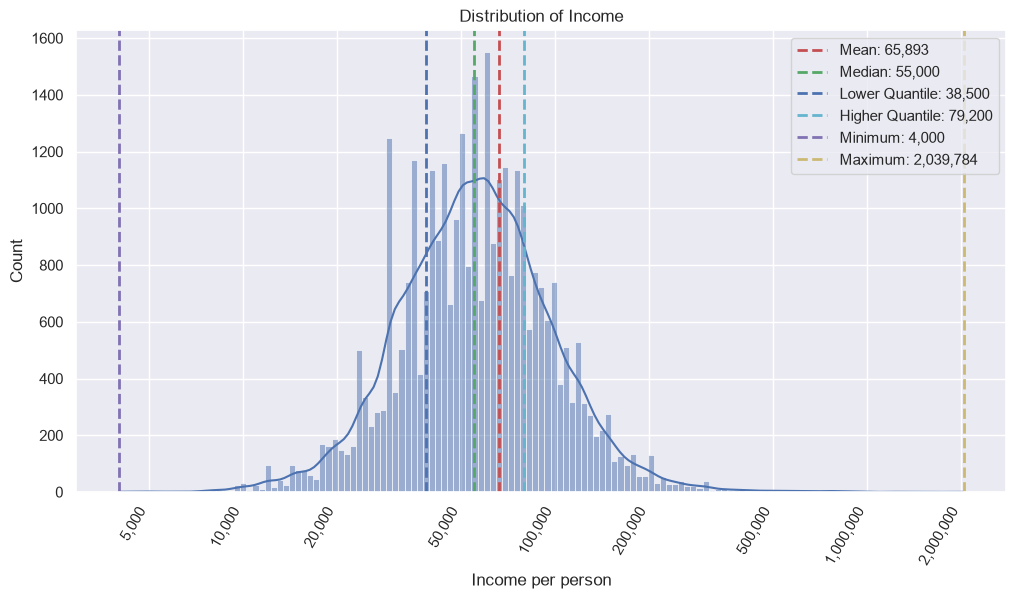

In [232]:
from matplotlib import scale
from  matplotlib.ticker import LogLocator
from matplotlib.ticker import FuncFormatter

min_val = person_incomes['Clean_person_income'].min()
max_val = person_incomes['Clean_person_income'].max()

mean_val = person_incomes['Clean_person_income'].mean()
median_val = person_incomes['Clean_person_income'].median()
lower_val = person_incomes['Clean_person_income'].quantile(0.25)
higher_val = person_incomes['Clean_person_income'].quantile(0.75)

plt.figure(figsize=(12,6))
incomes = sb.histplot(person_incomes,
                      x=person_incomes['Clean_person_income'],
                      bins='fd', 
                      stat='count',
                      log_scale=True,
                      kde=True,)
incomes.xaxis.set_major_formatter(FuncFormatter(lambda x, _:f'{int(x):,}'))
incomes.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 5]))

incomes.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
incomes.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
incomes.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower Quantile: {lower_val:,.0f}')
incomes.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher Quantile: {higher_val:,.0f}')

incomes.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
incomes.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

incomes.set_xlabel('Income per person')
incomes.set_title('Distribution of Income')
incomes.legend()

plt.xticks(rotation=60, horizontalalignment="right")


The graph shows the distribution of income peaks just between the median and mean values and to the little right of the median. This graph shows that most of the income are concentrated between the lower and higher quantile. Smaller spikes can be observed just before the lower quantile and after the higher quantile. This means that even though most of the borrowers have income located near the median, there are still income far away from it especially the income above the median that pulls the graph to skew right. To confirm this, the code below was used:

In [233]:
person_incomes['Clean_person_income'].skew() # Positive means right while negative numbers mean left

np.float64(9.747678448663162)

##### Home Ownership

The column can provide an assessment on how types of home ownership can relate to the ability of borrowers to pay their loans or default on their loans. This data can support borrower profiling, giving a clearer picture to what a typical borrower's profile looks like. To analyze the data, the following code was used:

In [234]:
home_ownerships = pd.read_csv('cleaned_data/cleaned_person_home_ownerships.csv')
home_ownerships.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clean_person_home_ownership  32581 non-null  str  
dtypes: str(1)
memory usage: 254.7 KB


In [235]:
home_ownerships.drop_duplicates(keep='last')

,Clean_person_home_ownership
32291,OTHER
32572,OWN
32579,MORTGAGE
32580,RENT


There are four types of home ownership in the column. Finding out the most frequent type can help in profiling the average borrower.

Text(0.5, 1.0, 'Distribution of Home Ownerships.')

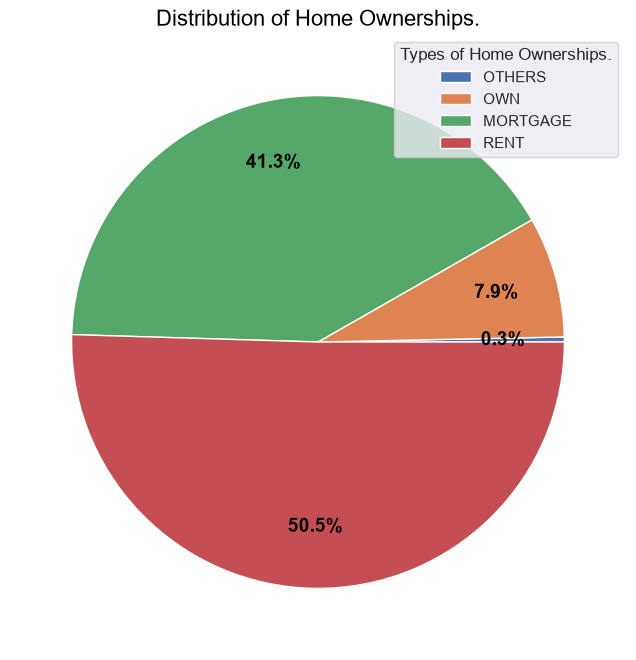

In [251]:
other = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'OTHER']
own = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'OWN']
mortgage = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'MORTGAGE']
rent = home_ownerships[home_ownerships['Clean_person_home_ownership'] == 'RENT']

home_counts = pd.DataFrame([
  other.count(),
  own.count(),
  mortgage.count(),
  rent.count()
],index=['OTHER','OWN','MORTGAGE','RENT'])

home_counts = home_counts.rename(columns={'Clean_person_home_ownership':'Type'})

ownership_labels = ['OTHERS','OWN','MORTGAGE','RENT']


fig, ax = plt.subplots(figsize=(8,8))
pie = ax.pie(home_counts['Type'], autopct='%1.1f%%',
             pctdistance=0.75, 
             textprops=dict(color='black', size=14, weight='bold'))

# Set pie chart legends
ax.legend(pie.wedges,['OTHERS','OWN','MORTGAGE','RENT'],
            title='Types of Home Ownerships.'
           )

# Set pie chart title
ax.set_title('Distribution of Home Ownerships.',  color='Black', fontsize="16")

The graph displays the distribution of home ownerships and based on the result, majority of the borrowers rent `(50.5%)`, followed by mortgage `(41.3%)`, then home ownership `(7.3%)` and others `(0.3%)`. This suggests that the average borrower is renting or paying mortgage for their home instead of owning them outright.

##### Employment Length

The column represents how long is the employment of a borrower in years. The employment length can be used to relate the amount of loan taken which can help the analyst in making an average borrower profile. The followind code was used:

In [237]:
employment_length = pd.read_csv('cleaned_data/cleaned_person_emp_length.csv')
employment_length.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Clean_person_emp_length  32581 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


In [238]:
employment_length.describe()

,Clean_person_emp_length
count,32581.000000
mean,4.760689
std,3.981013
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


The `0` in years could mean either unemployed, self-employed, semi-employed or still working less than a year. The huge gap between the third quantile and maximum value suggests a less concentrated or more spread out distribution of the top 25% of the data.

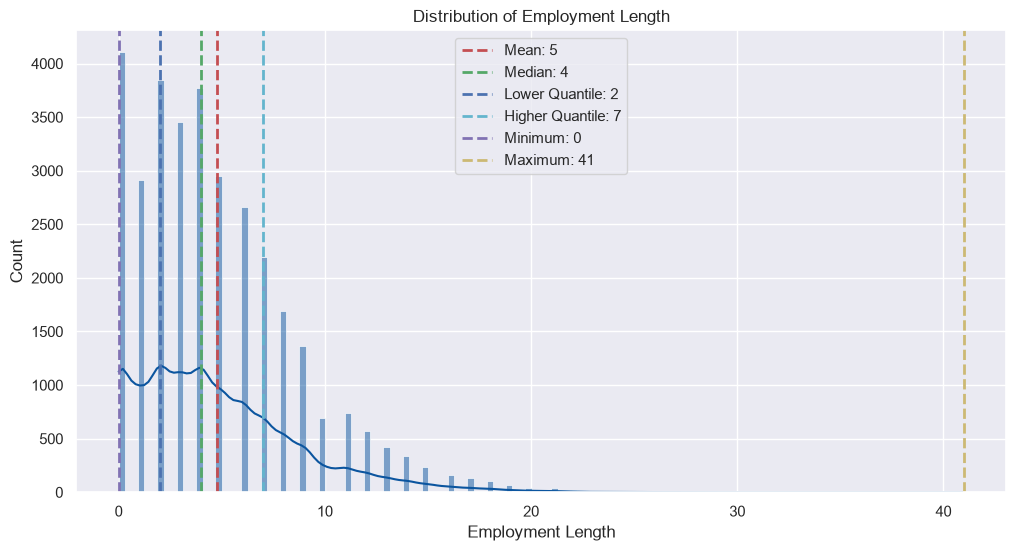

In [239]:


plt.figure(figsize=(12,6))
employment_length = employment_length.rename(columns={'Clean_person_emp_length':'Employment Length'})

palette = sb.color_palette("Blues")
bar_color = palette[5]

emp_length = sb.histplot(employment_length, x='Employment Length', bins='fd', stat='count',kde=True, color=bar_color)

mean_val = employment_length['Employment Length'].mean()
median_val = employment_length['Employment Length'].median()
lower_val = employment_length['Employment Length'].quantile(0.25)
higher_val = employment_length['Employment Length'].quantile(0.75)

min_val = employment_length['Employment Length'].min()
max_val = employment_length['Employment Length'].max()


emp_length.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_val:,.0f}')
emp_length.axvline(median_val, color='g', linestyle='--', linewidth=2, label=f'Median: {median_val:,.0f}')
emp_length.axvline(lower_val, color='b', linestyle='--', linewidth=2, label=f'Lower Quantile: {lower_val:,.0f}')
emp_length.axvline(higher_val, color='c', linestyle='--', linewidth=2, label=f'Higher Quantile: {higher_val:,.0f}')

emp_length.axvline(min_val, color='m', linestyle='--', linewidth=2, label=f'Minimum: {min_val:,.0f}')
emp_length.axvline(max_val, color='y', linestyle='--', linewidth=2, label=f'Maximum: {max_val:,.0f}')

emp_length.set_xlabel('Employment Length')
emp_length.set_title('Distribution of Employment Length')
emp_length.legend()


The graph shows that borrowers with less than a year of professional employment, or unemployed are the most frequent borrowers. The majority falls below the median of `4` years but the graph shows the mean of `5` years. This is due to the borrowers with longer employment pulling the skewness of the graph to the right. Their presence suggest a higher concentration of shorter employment while still having a group of longer employed borrowers.

##### Loan Intent

The data shows the purpose or intention behind the loan, indicating what borrowers plan to use the funds for. Analyzing this variable can help understand what the average borrower profile is and can help in analyzing patterns or behaviors of the borrowers. The code used are the following:

In [240]:
loan_intents = pd.read_csv('cleaned_data/cleaned_loan_intent.csv')
loan_intents.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Clean_loan_intent  32581 non-null  str  
dtypes: str(1)
memory usage: 254.7 KB


In [241]:
loan_intents.describe()

,Clean_loan_intent
count,32581
unique,6
top,EDUCATION
freq,6453


In [242]:
loan_intents.drop_duplicates(keep='last')

,Clean_loan_intent
32556,DEBT CONSOLIDATION
32571,VENTURE
32575,EDUCATION
32578,HOME IMPROVEMENT
32579,PERSONAL
32580,MEDICAL


In [246]:
debt_consol = loan_intents[loan_intents['Clean_loan_intent'] == 'DEBT CONSOLIDATION'].count()
venture = loan_intents[loan_intents['Clean_loan_intent'] == 'VENTURE'].count()
education = loan_intents[loan_intents['Clean_loan_intent'] == 'EDUCATION'].count()
home_improv = loan_intents[loan_intents['Clean_loan_intent'] == 'HOME IMPROVEMENT'].count()
personal = loan_intents[loan_intents['Clean_loan_intent'] == 'PERSONAL'].count()
medical = loan_intents[loan_intents['Clean_loan_intent'] == 'MEDICAL'].count()
df_intents = pd.DataFrame(
  [
    debt_consol,
    venture,
    education,
    home_improv,
    personal,
    medical
  ], index=['DEBT CONSOLIDATION','VENTURE','EDUCATION','HOME IMPROVEMENT','PERSONAL','MEDICAL']
)
df_intents = df_intents.rename(columns={'Clean_loan_intent':'Count'})

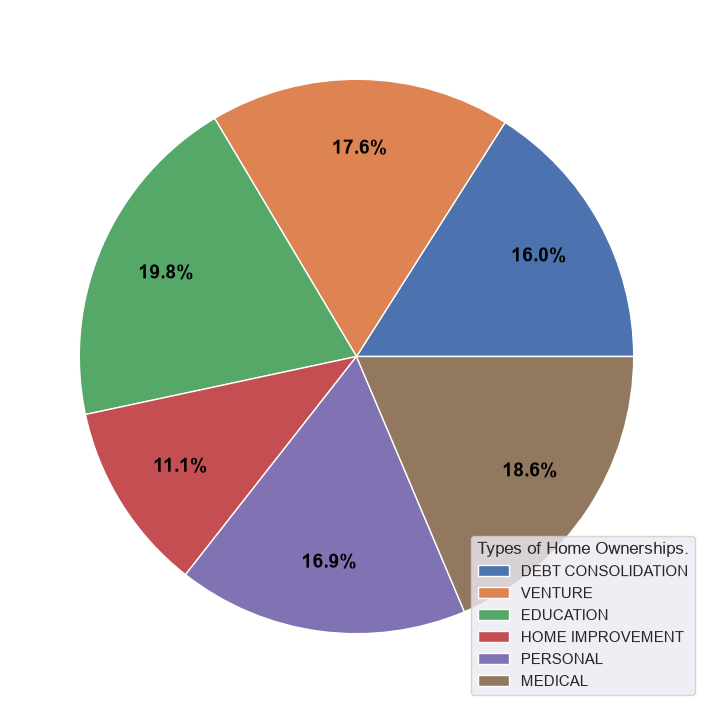

In [ ]:
intent_labels = np.array(['DEBT CONSOLIDATION','VENTURE','EDUCATION','HOME IMPROVEMENT','PERSONAL','MEDICAL'])

fig, ax = plt.subplots(figsize=(9,9))
pie = ax.pie(df_intents['Count'], autopct='%1.1f%%',
             pctdistance=0.75, 
             textprops=dict(color='black', size=14, weight='bold'))

ax.legend(pie.wedges,intent_labels,
            title='Types of Home Ownerships.'
           )

ax.set_title('Distribution of Types of Loan Intent')

##### Average Income per Home Ownership



Analysing the average income per home ownership helps us in establishing an average borrower profile. The result from this analysis can set expectations for the baseline averages of income for borrowers under the specific type of home ownership. The analyst used the following code:

In [ ]:
avg_income = pd.read_csv('cleaned_data/cleaned_person_incomes.csv')
avg_income['type_ownership'] = home_ownerships['Clean_person_home_ownership']
avg_income = avg_income.rename(columns={'Clean_person_income':'income'})

averages = avg_income.groupby('type_ownership')['income'].mean().reset_index()
averages = pd.DataFrame(averages)
averages

,type_ownership,income
0,MORTGAGE,80685.288902
1,OTHER,76387.803738
2,OWN,57834.812693
3,RENT,54997.747963


<Axes: xlabel='type_ownership', ylabel='income'>

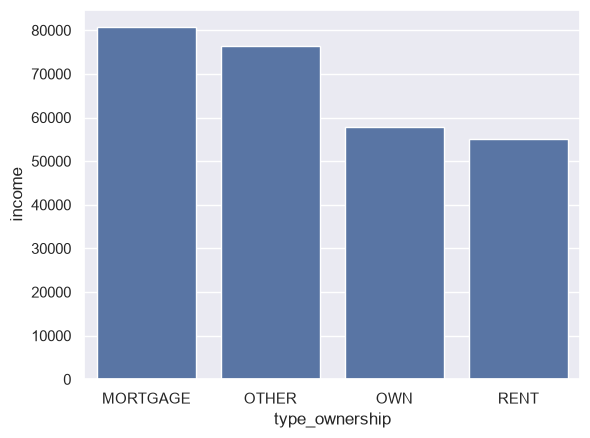

In [ ]:
sb.barplot(averages, x='type_ownership', y='income')

The bar chart shows that the home ownership with the highest average of income is `MORTGAGE`, followed by `OTHER`, `OWN` and `RENT`. The results suggest that even if most of the borrowers `(50.5%)` are renting, they have the lowest average of income especially compared to mortgage `(41.3%)`.